# Spatio-Temporal Exploratory Data Analysis
## Notebook 03: Air Quality Trends & Public Health Implications

### Research Motivation
Air pollution exhibits strong temporal dynamics and spatial heterogeneity.
Understanding these patterns is a prerequisite for accurate forecasting
and effective public health intervention.

### Key Questions
- How has ozone exceedance evolved over time?
- Which regions consistently experience higher risk?
- Are there detectable spatial or temporal clusters?


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
DATA_PATH = "../data/processed/air_quality_data_processed.csv"
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

In [16]:
required_cols = ["rolling_mean_3", "value", "high_risk", "value_lag_1", "state", "county", "year"]
for col in required_cols:
    assert col in df.columns, f"Column {col} missing!"

In [19]:
print(df.head())

   state_fips    state  county_fips   county  year  measure_id  \
0           1  Alabama         1001  Autauga  2001         292   
1           1  Alabama         1001  Autauga  2001         293   
2           1  Alabama         1001  Autauga  2001         294   
3           1  Alabama         1001  Autauga  2001         295   
4           1  Alabama         1001  Autauga  2001         296   

                                        measure_name          value  \
0  Number of days with maximum 8-hour average ozo...       3.000000   
1  Number of person-days with maximum 8-hour aver...  134667.000000   
2  Percent of days with PM2.5 levels over the Nat...       0.000000   
3  Number of person-days with PM2.5 over the Nati...       0.000000   
4  Annual average ambient concentrations of PM 2....      13.186807   

         data_origin  monitor_only  value_missing  value_lag_1  value_lag_3  \
0  Monitor & Modeled         False              0          NaN          NaN   
1  Monitor & Model

In [20]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218635 entries, 0 to 218634
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   state_fips      218635 non-null  int64  
 1   state           218635 non-null  object 
 2   county_fips     218635 non-null  int64  
 3   county          218635 non-null  object 
 4   year            218635 non-null  int64  
 5   measure_id      218635 non-null  int64  
 6   measure_name    218635 non-null  object 
 7   value           218635 non-null  float64
 8   data_origin     218635 non-null  object 
 9   monitor_only    218635 non-null  bool   
 10  value_missing   218635 non-null  int64  
 11  value_lag_1     215515 non-null  float64
 12  value_lag_3     209277 non-null  float64
 13  rolling_mean_3  212396 non-null  float64
 14  year_norm       218635 non-null  int64  
 15  high_risk       218635 non-null  int64  
dtypes: bool(1), float64(4), int64(7), object(4)
memory usage

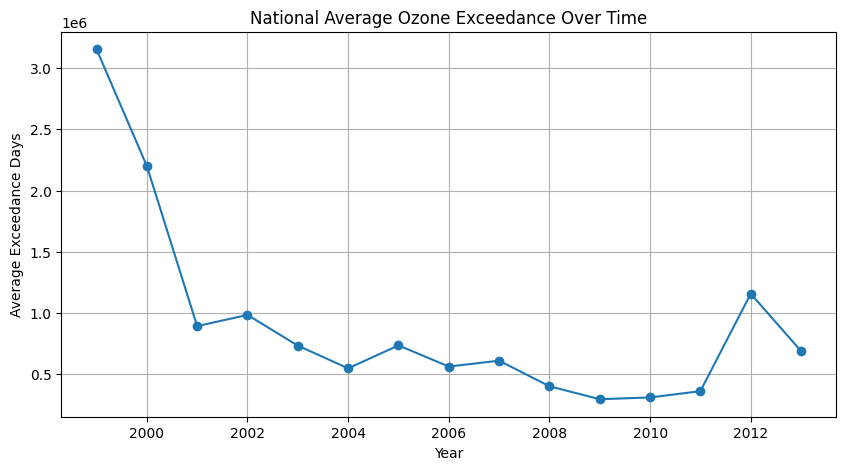

In [21]:
# Average ozone exceedance per year
national_trend = df.groupby("year")["value"].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(national_trend["year"], national_trend["value"], marker='o')
plt.title("National Average Ozone Exceedance Over Time")
plt.xlabel("Year")
plt.ylabel("Average Exceedance Days")
plt.grid(True)
plt.show()


Shows long-term changes in ozone exceedance across the US, highlighting potential regulatory or climate influences.

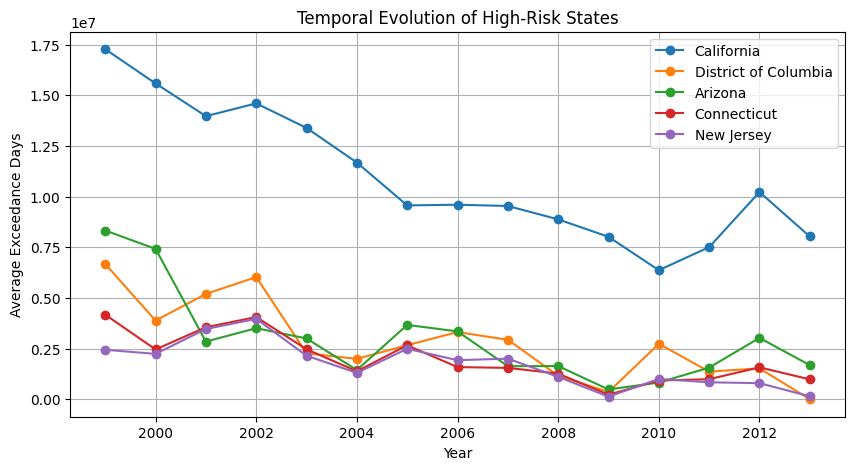

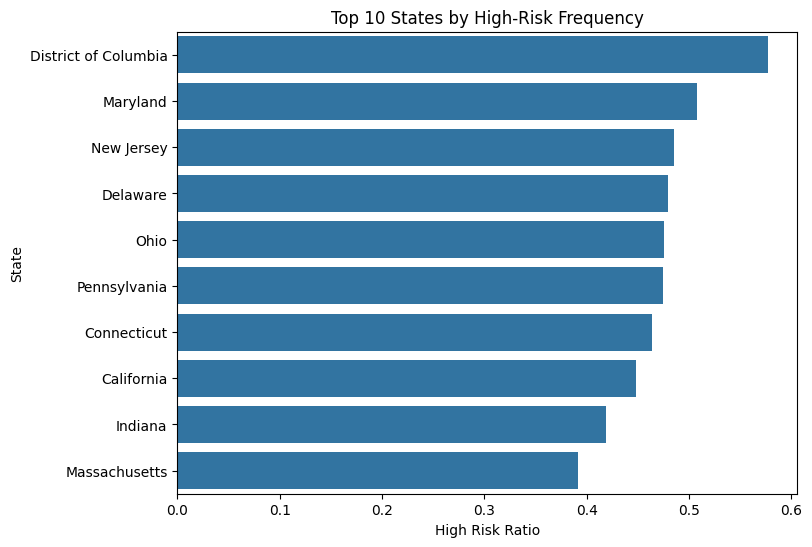

In [22]:
# Top 5 states by average ozone exceedance
top_states = df.groupby("state")["value"].mean().sort_values(ascending=False).head(5).index

plt.figure(figsize=(10,5))
for state in top_states:
    subset = df[df["state"] == state]
    yearly = subset.groupby("year")["value"].mean()
    plt.plot(yearly.index.values, yearly.values, marker='o', label=state)

plt.legend()
plt.title("Temporal Evolution of High-Risk States")
plt.xlabel("Year")
plt.ylabel("Average Exceedance Days")
plt.grid(True)
plt.show()

# High-risk frequency per state
state_risk = df.groupby("state")["high_risk"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=state_risk.head(10), x="high_risk", y="state")
plt.title("Top 10 States by High-Risk Frequency")
plt.xlabel("High Risk Ratio")
plt.ylabel("State")
plt.show()


In [23]:
# Variability of exceedance per county
county_variability = df.groupby(["state","county"])["value"].std().reset_index().sort_values("value", ascending=False)
print(county_variability.head(10))

# Persistent high-risk counties
persistent_risk = df.groupby(["state","county"])["high_risk"].mean().reset_index()
persistent_risk = persistent_risk.sort_values("high_risk", ascending=False)
print(persistent_risk.head(10))


           state          county         value
183   California     Los Angeles  3.534974e+08
200   California  San Bernardino  8.942592e+07
197   California       Riverside  8.613448e+07
2600       Texas          Harris  6.467365e+07
82       Arizona        Maricopa  4.986646e+07
587     Illinois            Cook  4.863878e+07
201   California       San Diego  3.748509e+07
194   California          Orange  3.362974e+07
174   California          Fresno  3.236643e+07
179   California            Kern  3.228966e+07
             state          county  high_risk
197     California       Riverside   0.875000
179     California            Kern   0.869231
174     California          Fresno   0.853846
180     California           Kings   0.848000
218     California          Tulare   0.838462
183     California     Los Angeles   0.821705
200     California  San Bernardino   0.815385
2222  Pennsylvania       Allegheny   0.784615
188     California          Merced   0.746032
184     California     

Counties with high variance or persistent high-risk exposure may need targeted interventions.

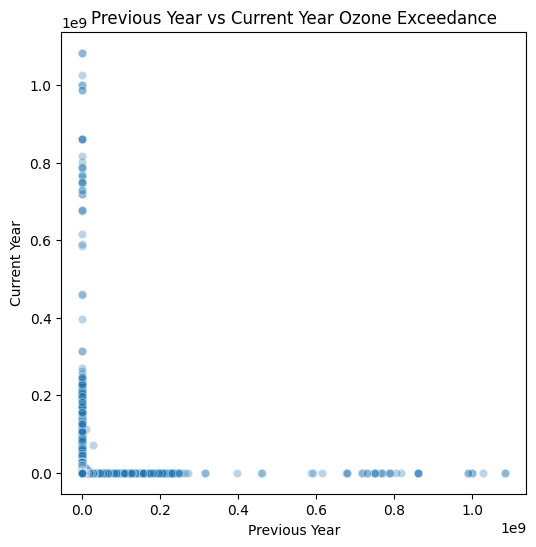

In [24]:
plt.figure(figsize=(6,6))
sns.scatterplot(data=df, x="value_lag_1", y="value", alpha=0.3)
plt.title("Previous Year vs Current Year Ozone Exceedance")
plt.xlabel("Previous Year")
plt.ylabel("Current Year")
plt.show()


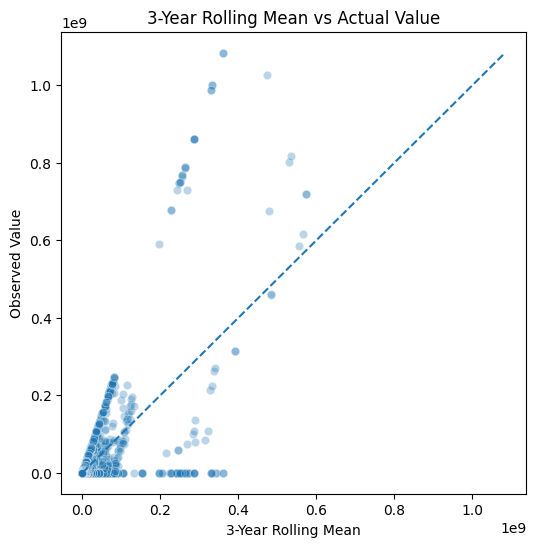

In [25]:
df_plot = df.dropna(subset=["rolling_mean_3","value"])

plt.figure(figsize=(6,6))
sns.scatterplot(data=df_plot, x="rolling_mean_3", y="value", alpha=0.3)
plt.plot([0, df_plot["value"].max()], [0, df_plot["value"].max()], linestyle="--")
plt.title("3-Year Rolling Mean vs Actual Value")
plt.xlabel("3-Year Rolling Mean")
plt.ylabel("Observed Value")
plt.show()


Useful for identifying early-warning thresholds using rolling statistics.

## Emerging Research Questions

1. **Prediction of Persistent High-Risk Counties:**  
   Can counties with persistent high risk be predicted several years in advance?

2. **Urban vs Rural Temporal Patterns:**  
   How do temporal pollution patterns differ between urban and rural areas?

3. **Regulatory Effects Across States:**  
   Are regulatory effects uniformly distributed across states?

4. **Early-Warning Thresholds:**  
   Can we define early-warning thresholds using rolling statistics?

5. **Volatility and Health Outcomes:**  
   How does air quality volatility correlate with long-term health outcomes?


In [29]:
import os

OUTPUT_STATE_RISK = "../data/processed/state_risk_summary.csv"
OUTPUT_COUNTY_RISK = "../data/processed/county_risk_summary.csv"

os.makedirs(os.path.dirname(OUTPUT_STATE_RISK), exist_ok=True)

state_risk.to_csv(OUTPUT_STATE_RISK, index=False)
persistent_risk.to_csv(OUTPUT_COUNTY_RISK, index=False)


Outputs are ready for downstream modeling or sharing with collaborators.